# Deep Learning Training — CIC-IDS-2018 (Fixed Pipeline)

**Same methodology as ML Fixed Pipeline notebook.**

| # | Change | Details |
|---|--------|---------|
| 1 | **Corrupt rows removed** | Negative values in time/duration features are physically impossible (CICFlowMeter bug) |
| 2 | **Correct scaling order** | Split train/test FIRST → fit scalers on train only → transform both |
| 3 | **Honest metrics** | Balanced Accuracy + per-class Recall added alongside standard metrics |

> **Note:** Duplicate removal and class balancing are intentionally NOT applied here.
> Each optimization is studied independently as per the research methodology.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, BatchNormalization, 
    Dropout, Dense, Flatten, LSTM, GRU,
    Bidirectional, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
print('=' * 80)
print('🚀 DEEP LEARNING TRAINING — CIC-IDS-2018 FIXED PIPELINE')
print('=' * 80)
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

🚀 DEEP LEARNING TRAINING — CIC-IDS-2018 FIXED PIPELINE
TensorFlow version: 2.20.0
Keras version: 3.13.0


## 2. Configuration

In [3]:
INPUT_FILE       = 'archive/full_df_binary_labels.csv'
BASE_MODEL_DIR   = 'trained_models/dl_fixed/'
TEST_SIZE        = 0.2
VALIDATION_SPLIT = 0.2
RANDOM_STATE     = 42
SAVE_MODELS      = True

# Training parameters
EPOCHS     = 12
BATCH_SIZE = 256
PATIENCE   = 10

# Per-model dataset size control (same as original)
MODEL_SAMPLE_SIZES = {
    'CNN' : 1000000,
    'LSTM': 200000
}

# Features that are physically impossible to be negative
NON_NEGATIVE_FEATURES = [
    'Flow Duration', 'Flow IAT Mean', 'Flow IAT Std',
    'Flow IAT Max',  'Flow IAT Min',  'Fwd IAT Tot',
    'Fwd IAT Mean',  'Fwd IAT Std',   'Fwd IAT Max',
    'Fwd IAT Min',   'Bwd IAT Tot',   'Bwd IAT Mean',
    'Bwd IAT Std',   'Bwd IAT Max',   'Bwd IAT Min',
    'Idle Mean',     'Idle Max',      'Idle Min',
    'Tot Fwd Pkts',  'Tot Bwd Pkts',  'TotLen Fwd Pkts',
    'TotLen Bwd Pkts', 'Flow Byts/s', 'Flow Pkts/s'
]

# Features to apply PowerTransformer (extreme skew)
POWER_TRANSFORMER_FEATURES = [
    'Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
    'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
    'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
    'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
    'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
    'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
    'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Len',
    'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Max',
    'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'Down/Up Ratio',
    'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg',
    'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts',
    'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts',
    'Fwd Act Data Pkts', 'Idle Mean', 'Idle Max', 'Idle Min'
]

# Features for StandardScaler (low skew)
STANDARD_SCALER_FEATURES = ['Fwd Seg Size Min']

# Features to leave unscaled (binary/categorical flags)
NO_SCALING_FEATURES = [
    'Protocol', 'RST Flag Cnt', 'PSH Flag Cnt',
    'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt'
]

os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print('✅ Configuration set')
print(f'   Output directory: {BASE_MODEL_DIR}')

✅ Configuration set
   Output directory: trained_models/dl_fixed/


## 3. Load Dataset

In [4]:
CHUNK_SIZE = 100000
MAX_ROWS   = None  # None = load all data

chunks     = []
total_rows = 0

print(f'\n📂 Loading data from: {INPUT_FILE}')
print('⏳ Reading in chunks...\n')

for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    chunks.append(chunk)
    total_rows += len(chunk)
    print(f'   Chunk {i+1}: {len(chunk):,} rows | Total: {total_rows:,}')

df_full = pd.concat(chunks, ignore_index=True)
del chunks

# Drop the string Label column — we only need Label_Binary
df_full = df_full.drop(columns=['Label'], errors='ignore')

print(f'\n✅ Dataset loaded')
print(f'   Rows   : {len(df_full):,}')
print(f'   Columns: {len(df_full.columns)}')
print(f'\nRaw class distribution:')
print(df_full['Label_Binary'].value_counts())


📂 Loading data from: archive/full_df_binary_labels.csv
⏳ Reading in chunks...

   Chunk 1: 100,000 rows | Total: 100,000
   Chunk 2: 100,000 rows | Total: 200,000
   Chunk 3: 100,000 rows | Total: 300,000
   Chunk 4: 100,000 rows | Total: 400,000
   Chunk 5: 100,000 rows | Total: 500,000
   Chunk 6: 100,000 rows | Total: 600,000
   Chunk 7: 100,000 rows | Total: 700,000
   Chunk 8: 100,000 rows | Total: 800,000
   Chunk 9: 100,000 rows | Total: 900,000
   Chunk 10: 100,000 rows | Total: 1,000,000
   Chunk 11: 100,000 rows | Total: 1,100,000
   Chunk 12: 100,000 rows | Total: 1,200,000
   Chunk 13: 100,000 rows | Total: 1,300,000
   Chunk 14: 100,000 rows | Total: 1,400,000
   Chunk 15: 100,000 rows | Total: 1,500,000
   Chunk 16: 100,000 rows | Total: 1,600,000
   Chunk 17: 100,000 rows | Total: 1,700,000
   Chunk 18: 100,000 rows | Total: 1,800,000
   Chunk 19: 100,000 rows | Total: 1,900,000
   Chunk 20: 100,000 rows | Total: 2,000,000
   Chunk 21: 100,000 rows | Total: 2,100,000
  

## 4. Data Cleaning
### Remove corrupt rows (impossible negative values)
CICFlowMeter has a known bug where timestamp overflows produce **negative** values
in duration and inter-arrival time features. These rows are corrupted and must be
removed before any training.

In [5]:
print('=' * 80)
print('🧹 REMOVING CORRUPT ROWS (impossible negative values)')
print('=' * 80)

before = len(df_full)
cols_to_check = [c for c in NON_NEGATIVE_FEATURES if c in df_full.columns]

print('\nNegative value counts per feature:')
for col in cols_to_check:
    n_bad = (df_full[col] < 0).sum()
    if n_bad > 0:
        print(f'  ⚠️  {col:<30} {n_bad:>8,} corrupt values')

corrupt_mask = (df_full[cols_to_check] < 0).any(axis=1)
df_full = df_full[~corrupt_mask].copy()

removed = before - len(df_full)
print(f'\n  Before : {before:,}')
print(f'  Removed: {removed:,} corrupt rows')
print(f'  After  : {len(df_full):,}')
print(f'\nClass distribution after cleaning:')
print(df_full['Label_Binary'].value_counts())

🧹 REMOVING CORRUPT ROWS (impossible negative values)

Negative value counts per feature:
  ⚠️  Flow Duration                        14 corrupt values
  ⚠️  Flow IAT Mean                        14 corrupt values
  ⚠️  Flow IAT Max                          3 corrupt values
  ⚠️  Flow IAT Min                         15 corrupt values
  ⚠️  Fwd IAT Tot                          14 corrupt values
  ⚠️  Fwd IAT Mean                         14 corrupt values
  ⚠️  Fwd IAT Max                           3 corrupt values
  ⚠️  Fwd IAT Min                          15 corrupt values
  ⚠️  Flow Pkts/s                          14 corrupt values

  Before : 16,232,943
  Removed: 15 corrupt rows
  After  : 16,232,928

Class distribution after cleaning:
Label_Binary
0    13484693
1     2748235
Name: count, dtype: int64


## 5. Prepare Features

In [6]:
print('\n' + '=' * 80)
print('🔧 PREPARING FEATURES')
print('=' * 80)

X_full = df_full.drop(['Label_Binary'], axis=1).select_dtypes(include=[np.number])
y_full = df_full['Label_Binary']

# Remove constant features (zero variance — useless for any model)
constant_cols = [c for c in X_full.columns if X_full[c].std() < 1e-10]
if constant_cols:
    print(f'\n  Dropping {len(constant_cols)} constant features (zero variance):')
    for c in constant_cols:
        print(f'    - {c}')
    X_full = X_full.drop(columns=constant_cols)

del df_full

# Store feature count for model building
NUM_FEATURES = X_full.shape[1]

print(f'\n✅ Features shape : {X_full.shape}')
print(f'✅ Labels shape   : {y_full.shape}')
print(f'   Number of features: {NUM_FEATURES}')
print(f'\nClass distribution:')
print(y_full.value_counts())


🔧 PREPARING FEATURES

✅ Features shape : (16232928, 57)
✅ Labels shape   : (16232928,)
   Number of features: 57

Class distribution:
Label_Binary
0    13484693
1     2748235
Name: count, dtype: int64


## 6. Helper Function — Prepare Data Per Model

In [7]:
def get_model_data_for_dl(X_full, y_full, model_name, sample_size=None,
                          test_size=0.2, random_state=42):
    """
    Prepare train/test data for a DL model.

    CORRECT ORDER:
      1. Sample (optional)
      2. Split train/test FIRST
      3. Fit scalers on TRAIN only
      4. Transform both sets with fitted scalers

    This prevents any form of data leakage.
    """
    X = X_full.copy()
    y = y_full.copy()

    # --- Optional sampling (for slow models like LSTM) ---
    if sample_size is not None and sample_size < len(X):
        print(f'   📊 Sampling {sample_size:,} rows (from {len(X):,})')
        X, _, y, _ = train_test_split(
            X, y, train_size=sample_size,
            random_state=random_state, stratify=y
        )
        print(f'   Sampled class distribution: {y.value_counts().to_dict()}')
    else:
        print(f'   📊 Using full dataset: {len(X):,} rows')

    # --- STEP 1: Split FIRST — test set is isolated immediately ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    print(f'   Train: {len(X_train):,} rows | Test: {len(X_test):,} rows')

    X_train = X_train.copy()
    X_test  = X_test.copy()

    # --- STEP 2: Fit scalers on TRAIN only, transform both ---
    print('   🔧 Scaling (fit on train only — no leakage)...')
    scalers = {}

    # PowerTransformer — handles extreme skew and negative values
    power_cols = [
        c for c in POWER_TRANSFORMER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if power_cols:
        pt = PowerTransformer(method='yeo-johnson', standardize=True)
        pt.fit(X_train[power_cols])                         # ← train only
        X_train[power_cols] = pt.transform(X_train[power_cols])
        X_test[power_cols]  = pt.transform(X_test[power_cols])
        scalers['power'] = pt
        print(f'      PowerTransformer : {len(power_cols)} features')

    # StandardScaler — for low-skew features
    std_cols = [
        c for c in STANDARD_SCALER_FEATURES
        if c in X_train.columns and X_train[c].std() > 1e-10
    ]
    if std_cols:
        ss = StandardScaler()
        ss.fit(X_train[std_cols])                           # ← train only
        X_train[std_cols] = ss.transform(X_train[std_cols])
        X_test[std_cols]  = ss.transform(X_test[std_cols])
        scalers['standard'] = ss
        print(f'      StandardScaler   : {len(std_cols)} features')

    no_scale = [c for c in NO_SCALING_FEATURES if c in X_train.columns]
    if no_scale:
        print(f'      Unscaled         : {len(no_scale)} binary/flag features')

    print('   ✅ Scaling complete')
    return X_train, X_test, y_train, y_test, scalers


print('✅ Helper function defined')

✅ Helper function defined


## 7. Model Builders

In [8]:
def build_cnn_model(input_shape):
    """
    Build 1D CNN model for network traffic classification.
    """
    model = Sequential([
        tf.keras.layers.Reshape((input_shape[0], 1), input_shape=input_shape),

        # Conv Block 1
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 2
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        # Conv Block 3
        Conv1D(256, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.4),

        # Dense layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


def build_lstm_model(input_shape):
    """
    Build LSTM model for network traffic classification.
    """
    model = Sequential([
        tf.keras.layers.Reshape((input_shape[0], 1), input_shape=input_shape),

        # LSTM layers
        LSTM(128, return_sequences=True),
        Dropout(0.3),
        BatchNormalization(),

        LSTM(64, return_sequences=False),
        Dropout(0.3),
        BatchNormalization(),

        # Dense layers
        Dense(128, activation='relu'),
        Dropout(0.4),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    return model


model_builders = {
    'CNN' : build_cnn_model,
    'LSTM': build_lstm_model
}

print(f'\n✅ Defined {len(model_builders)} DL models to train')


✅ Defined 2 DL models to train


## 8. Train All Models

In [9]:
results       = {}
histories     = {}
saved_scalers = {}

for model_name, model_builder in model_builders.items():
    print('\n' + '=' * 80)
    print(f'🚀 TRAINING: {model_name}')
    print('=' * 80)
    
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower())
    os.makedirs(model_dir, exist_ok=True)
    print(f'📁 Model directory: {model_dir}')
    
    sample_size = MODEL_SAMPLE_SIZES.get(model_name, None)
    
    # Prepare data — split first, scale on train only
    X_train, X_test, y_train, y_test, scalers = get_model_data_for_dl(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
    saved_scalers[model_name] = scalers
    
    # Build model
    print(f'\n🔨 Building {model_name} model...')
    model = model_builder((NUM_FEATURES,))
    
    print(f'\n📋 Model Architecture:')
    model.summary()
    
    # Callbacks
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=os.path.join(model_dir, 'best_model.h5'),
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ]
    
    # Train
    print(f'\n⏱️  Training...')
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=VALIDATION_SPLIT,
        callbacks=callbacks,
        verbose=1
    )
    train_time = time.time() - start_time
    print(f'\n✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)')
    
    # Evaluate
    print(f'\n🔮 Evaluating on test set...')
    start_time = time.time()
    
    test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
        X_test, y_test, batch_size=BATCH_SIZE, verbose=1
    )
    
    # Predictions for sklearn metrics
    y_pred_proba = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    y_pred       = (y_pred_proba > 0.5).astype(int).flatten()
    
    pred_time = time.time() - start_time
    print(f'✅ Evaluation completed in {pred_time:.2f} seconds')
    
    # Calculate binary metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall    = recall_score(y_test, y_pred, average='binary')
    f1        = f1_score(y_test, y_pred, average='binary')
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    cm        = confusion_matrix(y_test, y_pred)

    # Per-class metrics from confusion matrix
    TN, FP, FN, TP = cm[0][0], cm[0][1], cm[1][0], cm[1][1]
    benign_recall     = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    attack_recall     = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    benign_precision  = TN / (TN + FN) if (TN + FN) > 0 else 0.0
    attack_precision  = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    balanced_accuracy = (benign_recall + attack_recall) / 2

    # Print metrics
    print(f'\n📊 RESULTS:')
    print(f'   Loss:               {test_loss:.4f}')
    print(f'   Balanced Accuracy:  {balanced_accuracy:.4f}')
    print(f'   F1 Macro:           {f1_macro:.4f}')
    print(f'   Benign Recall:      {benign_recall:.4f}')
    print(f'   Attack Recall:      {attack_recall:.4f}')
    print(f'   Benign Precision:   {benign_precision:.4f}')
    print(f'   Attack Precision:   {attack_precision:.4f}')
    print(f'   Plain Accuracy:     {accuracy:.4f}  ⚠️  (shown for reference only)')
    
    print(f'\n🕐 TIME:')
    print(f'   Train: {train_time:.2f}s ({train_time/60:.2f} min)')
    print(f'   Test:  {pred_time:.2f}s')
    
    print(f'\n📈 DATASET INFO:')
    print(f'   Sample size: {len(X_train) + len(X_test):,} total')
    print(f'   Train samples: {len(X_train):,}')
    print(f'   Test samples:  {len(X_test):,}')
    print(f'   Epochs trained: {len(history.history["loss"])}')
    
    print(f'\n🎯 Confusion Matrix:')
    print(cm)
    
    # Store results
    results[model_name] = {
        # Honest metrics (primary)
        'balanced_accuracy': float(balanced_accuracy),
        'f1_macro':          float(f1_macro),
        'benign_recall':     float(benign_recall),
        'attack_recall':     float(attack_recall),
        'benign_precision':  float(benign_precision),
        'attack_precision':  float(attack_precision),
        # Standard metrics (for reference / paper comparison)
        'accuracy':          float(accuracy),
        'precision':         float(precision),
        'recall':            float(recall),
        'f1_score':          float(f1),
        'loss':              float(test_loss),
        # Meta
        'train_time':        train_time,
        'pred_time':         pred_time,
        'confusion_matrix':  cm,
        'predictions':       y_pred,
        'sample_size':       len(X_train) + len(X_test),
        'train_samples':     len(X_train),
        'test_samples':      len(X_test),
        'epochs_trained':    len(history.history['loss'])
    }
    
    histories[model_name] = history
    
    # Save
    if SAVE_MODELS:
        model_path = os.path.join(model_dir, 'final_model.h5')
        model.save(model_path)
        print(f'\n💾 Final model saved: {model_path}')
        
        if scalers:
            scaler_path = os.path.join(model_dir, 'scalers.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(scalers, f)
            print(f'💾 Scalers saved: {scaler_path}')
        
        # Save history
        history_path = os.path.join(model_dir, 'history.pkl')
        with open(history_path, 'wb') as f:
            pickle.dump(history.history, f)
        print(f'💾 Training history saved: {history_path}')
        
        # Save metadata
        metadata = {
            'model_name':       model_name,
            'num_features':     NUM_FEATURES,
            'sample_size':      sample_size,
            'train_samples':    len(X_train),
            'test_samples':     len(X_test),
            'features':         X_train.shape[1],
            'epochs':           EPOCHS,
            'epochs_trained':   len(history.history['loss']),
            'batch_size':       BATCH_SIZE,
            'train_time':       train_time,
            'metrics':          {
                'balanced_accuracy': float(balanced_accuracy),
                'f1_macro':          float(f1_macro),
                'benign_recall':     float(benign_recall),
                'attack_recall':     float(attack_recall),
                'accuracy':          float(accuracy),
                'precision':         float(precision),
                'recall':            float(recall),
                'f1_score':          float(f1),
                'loss':              float(test_loss)
            },
            'pipeline_fixes':   ['corrupt_rows_removed', 'split_before_scale']
        }
        
        metadata_path = os.path.join(model_dir, 'metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f'💾 Metadata saved: {metadata_path}')

print('\n' + '=' * 80)
print('✅ ALL MODELS TRAINED & TESTED!')
print('=' * 80)


🚀 TRAINING: CNN
📁 Model directory: trained_models/dl_fixed/cnn
   📊 Sampling 1,000,000 rows (from 16,232,928)
   Sampled class distribution: {0: 830700, 1: 169300}
   Train: 800,000 rows | Test: 200,000 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 50 features
      StandardScaler   : 1 features
      Unscaled         : 6 binary/flag features
   ✅ Scaling complete

🔨 Building CNN model...

📋 Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 57, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 57, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 57, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 28, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 14, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,369 (2.36 MB)

 Trainable params: 616,961 (2.35 MB)

...


Epoch 5: finished saving model to trained_models/dl_fixed/lstm\best_model.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.9827 - loss: 0.0759 - precision: 0.9771 - recall: 0.9192 - val_accuracy: 0.9840 - val_loss: 0.0646 - val_precision: 0.9769 - val_recall: 0.9276 - learning_rate: 0.0010
Epoch 6/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9831 - loss: 0.0734 - precision: 0.9806 - recall: 0.9177
Epoch 6: val_loss did not improve from 0.06461
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.9829 - loss: 0.0745 - precision: 0.9793 - recall: 0.9187 - val_accuracy: 0.9833 - val_loss: 0.0724 - val_precision: 0.9707 - val_recall: 0.9294 - learning_rate: 0.0010
Epoch 7/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9841 - loss: 0.0705 - precision: 0.9818 - recall: 0.9239
Epoch 7: val_loss improved from 0.06461 to 0.05473, saving model to trained_models/dl_fixed/lstm\best_model.h5



Epoch 7: finished saving model to trained_models/dl_fixed/lstm\best_model.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.9850 - loss: 0.0678 - precision: 0.9837 - recall: 0.9266 - val_accuracy: 0.9883 - val_loss: 0.0547 - val_precision: 0.9905 - val_recall: 0.9398 - learning_rate: 0.0010
Epoch 8/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9855 - loss: 0.0663 - precision: 0.9873 - recall: 0.9269
Epoch 8: val_loss did not improve from 0.05473
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 117ms/step - accuracy: 0.9858 - loss: 0.0655 - precision: 0.9879 - recall: 0.9277 - val_accuracy: 0.9842 - val_loss: 0.0670 - val_precision: 0.9816 - val_recall: 0.9237 - learning_rate: 0.0010
Epoch 9/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.9855 - loss: 0.0649 - precision: 0.9869 - recall: 0.9275
Epoch 9: val_loss improved from 0.05473 to 0.05381, saving model to trained_models/dl_fixed/lstm\best_model.h5



Epoch 9: finished saving model to trained_models/dl_fixed/lstm\best_model.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 59s 118ms/step - accuracy: 0.9864 - loss: 0.0634 - precision: 0.9892 - recall: 0.9296 - val_accuracy: 0.9887 - val_loss: 0.0538 - val_precision: 0.9916 - val_recall: 0.9409 - learning_rate: 0.0010
Epoch 10/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9875 - loss: 0.0593 - precision: 0.9908 - recall: 0.9355
Epoch 10: val_loss did not improve from 0.05381
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.9870 - loss: 0.0603 - precision: 0.9903 - recall: 0.9325 - val_accuracy: 0.9876 - val_loss: 0.0598 - val_precision: 0.9849 - val_recall: 0.9409 - learning_rate: 0.0010
Epoch 11/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.9868 - loss: 0.0616 - precision: 0.9907 - recall: 0.9301
Epoch 11: val_loss improved from 0.05381 to 0.05137, saving model to trained_models/dl_fixed/lstm\best_model.h5



Epoch 11: finished saving model to trained_models/dl_fixed/lstm\best_model.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 63s 125ms/step - accuracy: 0.9870 - loss: 0.0605 - precision: 0.9912 - recall: 0.9314 - val_accuracy: 0.9889 - val_loss: 0.0514 - val_precision: 0.9943 - val_recall: 0.9398 - learning_rate: 0.0010
Epoch 12/12
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.9873 - loss: 0.0589 - precision: 0.9917 - recall: 0.9325
Epoch 12: val_loss did not improve from 0.05137
500/500 ━━━━━━━━━━━━━━━━━━━━ 60s 121ms/step - accuracy: 0.9873 - loss: 0.0592 - precision: 0.9916 - recall: 0.9326 - val_accuracy: 0.9888 - val_loss: 0.0515 - val_precision: 0.9941 - val_recall: 0.9394 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 11.

✅ Training completed in 719.21 seconds (11.99 minutes)

🔮 Evaluating on test set...
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9881 - loss: 0.0531 - precision: 0.9953 - recall: 0.9343


✅ Evaluation completed in 15.46 seconds

📊 RESULTS:
   Loss:               0.0531
   Balanced Accuracy:  0.9667
   F1 Macro:           0.9784
   Benign Recall:      0.9991
   Attack Recall:      0.9343
   Benign Precision:   0.9868
   Attack Precision:   0.9953
   Plain Accuracy:     0.9881  ⚠️  (shown for reference only)

🕐 TIME:
   Train: 719.21s (11.99 min)
   Test:  15.46s

📈 DATASET INFO:
   Sample size: 200,000 total
   Train samples: 160,000
   Test samples:  40,000
   Epochs trained: 12

🎯 Confusion Matrix:
[[33198    30]
 [  445  6327]]

💾 Final model saved: trained_models/dl_fixed/lstm\final_model.h5
💾 Scalers saved: trained_models/dl_fixed/lstm\scalers.pkl
💾 Training history saved: trained_models/dl_fixed/lstm\history.pkl
💾 Metadata saved: trained_models/dl_fixed/lstm\metadata.pkl

✅ ALL MODELS TRAINED & TESTED!


## 9. Results Summary

In [10]:
print('\n' + '=' * 80)
print('📊 FINAL RESULTS — HONEST METRICS')
print('=' * 80)

summary_df = pd.DataFrame(results).T
summary_df = summary_df.sort_values('balanced_accuracy', ascending=False)

display_cols = [
    'balanced_accuracy', 'f1_macro',
    'benign_recall', 'attack_recall',
    'benign_precision', 'attack_precision',
    'loss', 'train_time', 'sample_size'
]

print('\nRanked by Balanced Accuracy (primary metric):')
print(summary_df[display_cols].to_string())

print('\n⚠️  NOTE: Plain accuracy is misleading on imbalanced data.')
print('    Balanced Accuracy treats both classes equally.')
print('    Benign Recall  = how many legitimate flows are correctly identified')
print('    Attack Recall  = how many attacks are correctly detected')

summary_df


📊 FINAL RESULTS — HONEST METRICS

Ranked by Balanced Accuracy (primary metric):
     balanced_accuracy  f1_macro benign_recall attack_recall benign_precision attack_precision      loss  train_time sample_size
CNN           0.969745  0.980522      0.999296      0.940195          0.98795         0.996338  0.048206  578.109186     1000000
LSTM          0.966693  0.978359      0.999097      0.934288         0.986773         0.995281  0.053135  719.210517      200000

⚠️  NOTE: Plain accuracy is misleading on imbalanced data.
    Balanced Accuracy treats both classes equally.
    Benign Recall  = how many legitimate flows are correctly identified
    Attack Recall  = how many attacks are correctly detected


,balanced_accuracy,f1_macro,benign_recall,attack_recall,benign_precision,attack_precision,accuracy,precision,recall,f1_score,loss,train_time,pred_time,confusion_matrix,predictions,sample_size,train_samples,test_samples,epochs_trained
CNN,0.969745,0.980522,0.999296,0.940195,0.98795,0.996338,0.98929,0.996338,0.940195,0.967453,0.048206,578.109186,8.48063,"[[166023, 117], [2025, 31835]]","[0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, ...",1000000,800000,200000,12
LSTM,0.966693,0.978359,0.999097,0.934288,0.986773,0.995281,0.988125,0.995281,0.934288,0.963821,0.053135,719.210517,15.457432,"[[33198, 30], [445, 6327]]","[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",200000,160000,40000,12


## 10. Visualisation — Training History


📊 Creating training history plots...
✅ Saved → trained_models/dl_fixed/training_history_fixed.png


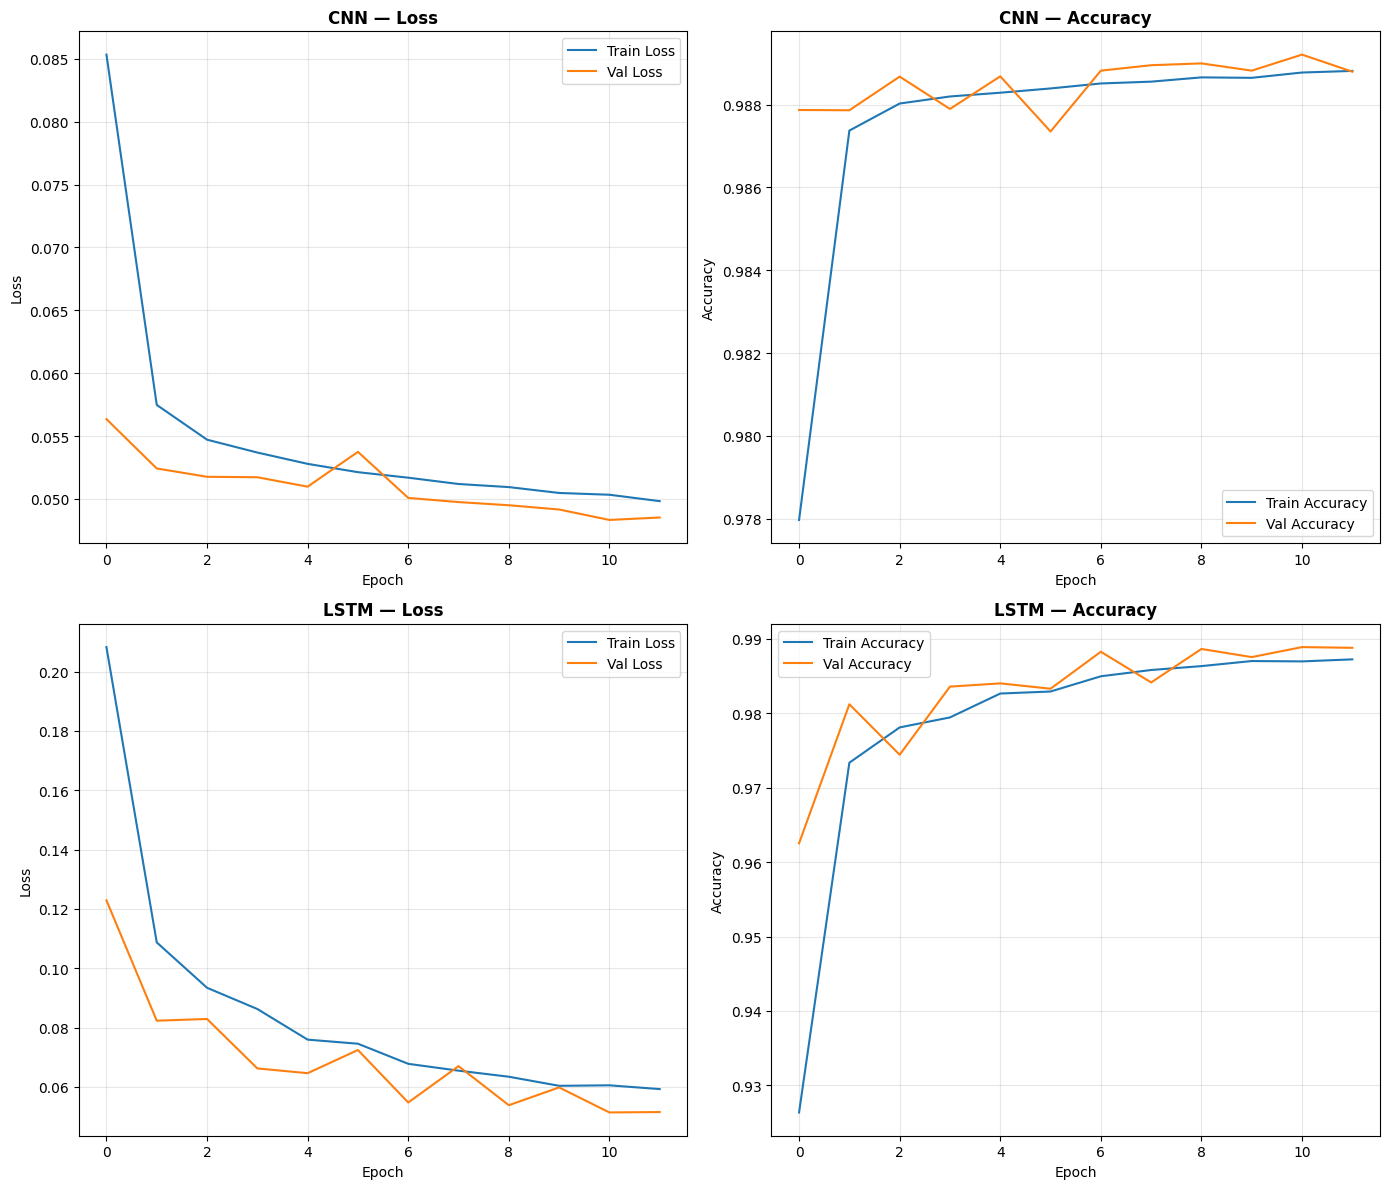

In [11]:
print('\n📊 Creating training history plots...')

fig, axes = plt.subplots(len(model_builders), 2,
                         figsize=(14, 6 * len(model_builders)))
if len(model_builders) == 1:
    axes = axes.reshape(1, -1)

for idx, (model_name, history) in enumerate(histories.items()):
    # Loss
    axes[idx, 0].plot(history.history['loss'],     label='Train Loss')
    axes[idx, 0].plot(history.history['val_loss'], label='Val Loss')
    axes[idx, 0].set_title(f'{model_name} — Loss', fontweight='bold')
    axes[idx, 0].set_xlabel('Epoch')
    axes[idx, 0].set_ylabel('Loss')
    axes[idx, 0].legend()
    axes[idx, 0].grid(alpha=0.3)

    # Accuracy
    axes[idx, 1].plot(history.history['accuracy'],     label='Train Accuracy')
    axes[idx, 1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[idx, 1].set_title(f'{model_name} — Accuracy', fontweight='bold')
    axes[idx, 1].set_xlabel('Epoch')
    axes[idx, 1].set_ylabel('Accuracy')
    axes[idx, 1].legend()
    axes[idx, 1].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_MODEL_DIR, 'training_history_fixed.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {plot_path}')
plt.show()

## 11. Visualisation — Performance Comparison

✅ Saved → trained_models/dl_fixed/model_comparison_fixed.png


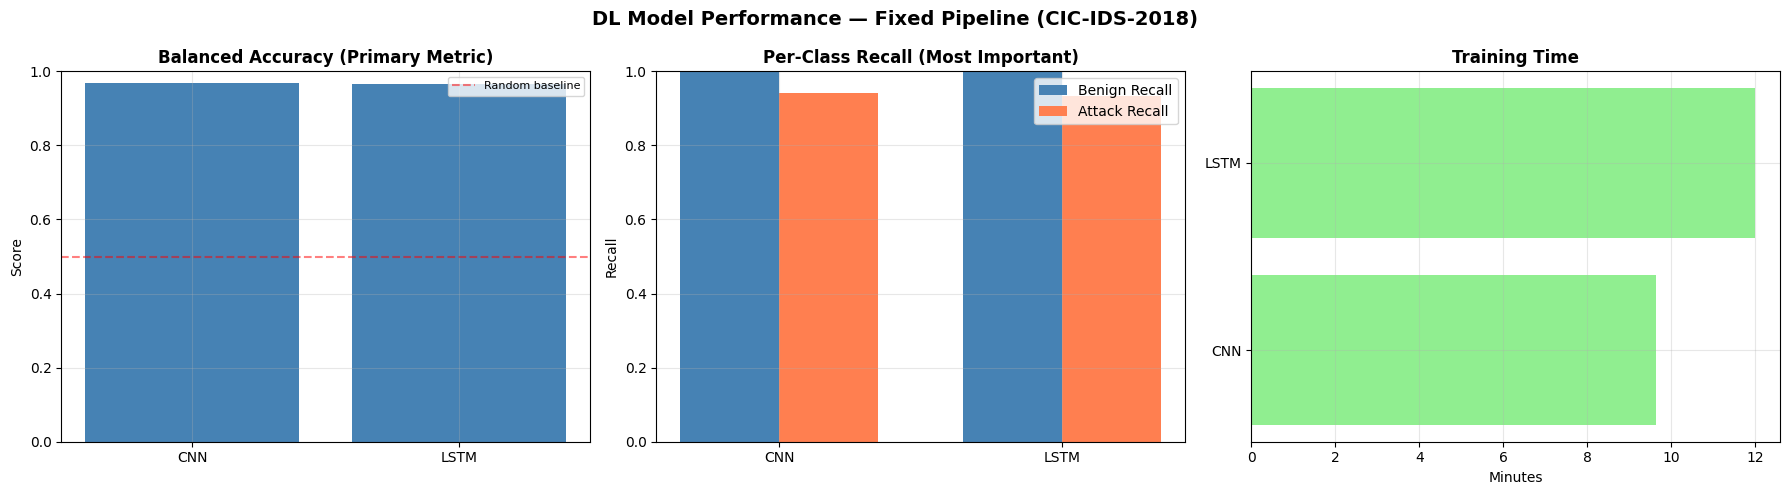

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DL Model Performance — Fixed Pipeline (CIC-IDS-2018)',
             fontsize=14, fontweight='bold')

model_names = summary_df.index.tolist()

# Balanced Accuracy
axes[0].bar(model_names, summary_df['balanced_accuracy'], color='steelblue')
axes[0].set_title('Balanced Accuracy (Primary Metric)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Random baseline')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Per-class Recall
x     = np.arange(len(model_names))
width = 0.35
axes[1].bar(x - width/2, summary_df['benign_recall'], width,
            label='Benign Recall', color='steelblue')
axes[1].bar(x + width/2, summary_df['attack_recall'], width,
            label='Attack Recall', color='coral')
axes[1].set_title('Per-Class Recall (Most Important)', fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

# Training time
axes[2].barh(model_names, summary_df['train_time'] / 60, color='lightgreen')
axes[2].set_title('Training Time', fontweight='bold')
axes[2].set_xlabel('Minutes')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_MODEL_DIR, 'model_comparison_fixed.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {plot_path}')
plt.show()

## 12. Confusion Matrices

   📊 Sampling 1,000,000 rows (from 16,232,928)
   Sampled class distribution: {0: 830700, 1: 169300}
   Train: 800,000 rows | Test: 200,000 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 50 features
      StandardScaler   : 1 features
      Unscaled         : 6 binary/flag features
   ✅ Scaling complete


   📊 Sampling 200,000 rows (from 16,232,928)
   Sampled class distribution: {0: 166140, 1: 33860}
   Train: 160,000 rows | Test: 40,000 rows
   🔧 Scaling (fit on train only — no leakage)...
      PowerTransformer : 50 features
      StandardScaler   : 1 features
      Unscaled         : 6 binary/flag features
   ✅ Scaling complete


✅ Saved → trained_models/dl_fixed/confusion_matrices_fixed.png


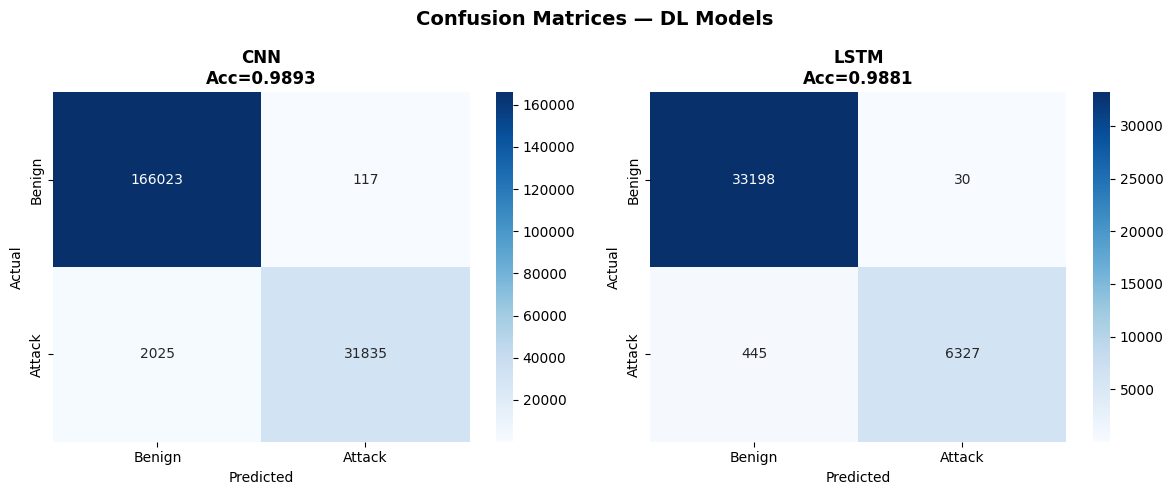

In [13]:
fig, axes = plt.subplots(1, len(model_builders),
                         figsize=(6 * len(model_builders), 5))
if len(model_builders) == 1:
    axes = [axes]

for idx, (model_name) in enumerate(model_builders.keys()):
    # Re-generate predictions
    sample_size = MODEL_SAMPLE_SIZES.get(model_name, None)
    X_tr, X_te, y_tr, y_te, _ = get_model_data_for_dl(
        X_full, y_full, model_name, sample_size, TEST_SIZE, RANDOM_STATE
    )
    # Load best saved model
    best_path = os.path.join(BASE_MODEL_DIR, model_name.lower(), 'best_model.h5')
    best_model = tf.keras.models.load_model(best_path)
    y_pred_p   = best_model.predict(X_te, batch_size=BATCH_SIZE, verbose=0)
    y_pred     = (y_pred_p > 0.5).astype(int).flatten()

    cm  = confusion_matrix(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    axes[idx].set_title(f'{model_name}\nAcc={acc:.4f}',
                        fontweight='bold')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — DL Models', fontsize=14, fontweight='bold')
plt.tight_layout()
cm_path = os.path.join(BASE_MODEL_DIR, 'confusion_matrices_fixed.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
print(f'✅ Saved → {cm_path}')
plt.show()

## 13. Final Summary

In [14]:
print('\n' + '=' * 80)
print('🎉 TRAINING COMPLETE — FIXED PIPELINE')
print('=' * 80)

print('\n📋 What was fixed in this notebook:')
print('   ✅ Corrupt rows removed  (impossible negative values from CICFlowMeter bug)')
print('   ✅ Scaling done correctly (split first → fit on train only)')
print('   ✅ Honest metrics used   (Balanced Accuracy + per-class Recall)')

print('\n📊 Models Ranked by Balanced Accuracy:')
for rank, (model_name, row) in enumerate(
        sorted(results.items(),
               key=lambda x: x[1]['balanced_accuracy'],
               reverse=True), 1):
    print(f'   {rank}. {model_name:<6}  '
          f'Bal.Acc={row["balanced_accuracy"]:.4f}  '
          f'Benign Recall={row["benign_recall"]:.4f}  '
          f'Attack Recall={row["attack_recall"]:.4f}  '
          f'({row["train_time"]/60:.1f} min)')

print(f'\n📁 All models saved to: {BASE_MODEL_DIR}')
print('\n💡 Key reminder:')
print('   A good IDS model needs HIGH recall on BOTH classes.')
print('   Low Benign Recall → too many false alarms.')
print('   Low Attack Recall → attacks are slipping through.')


🎉 TRAINING COMPLETE — FIXED PIPELINE

📋 What was fixed in this notebook:
   ✅ Corrupt rows removed  (impossible negative values from CICFlowMeter bug)
   ✅ Scaling done correctly (split first → fit on train only)
   ✅ Honest metrics used   (Balanced Accuracy + per-class Recall)

📊 Models Ranked by Balanced Accuracy:
   1. CNN     Bal.Acc=0.9697  Benign Recall=0.9993  Attack Recall=0.9402  (9.6 min)
   2. LSTM    Bal.Acc=0.9667  Benign Recall=0.9991  Attack Recall=0.9343  (12.0 min)

📁 All models saved to: trained_models/dl_fixed/

💡 Key reminder:
   A good IDS model needs HIGH recall on BOTH classes.
   Low Benign Recall → too many false alarms.
   Low Attack Recall → attacks are slipping through.
